#  Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme('notebook', palette='muted')

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, accuracy_score



# Load Dataset

In [2]:
filepath = r'D:/HopeAI/Assignments/Deep Learning/'
fashion_train=pd.read_csv(filepath+"fashion-mnist_train.csv")
fashion_test=pd.read_csv(filepath+"fashion-mnist_test.csv")
print("Fashion MNIST train -  rows:",fashion_train.shape[0]," columns:", fashion_train.shape[1])
print("Fashion MNIST test -  rows:",fashion_test.shape[0]," columns:", fashion_test.shape[1])
fashion_train


Fashion MNIST train -  rows: 60000  columns: 785
Fashion MNIST test -  rows: 10000  columns: 785


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Preprocessing 

In [3]:
# data preprocessing
def data_preprocessing(inpdata, targetcol, no_classes, img_rows, img_cols):
    out_y = keras.utils.to_categorical(inpdata[targetcol], no_classes)
    num_images = inpdata.shape[0]
    x_as_array = inpdata.values[:,1:]
    x_shaped_array = x_as_array.reshape(num_images, img_rows, img_cols, 1)
    out_x = x_shaped_array / 255
    return out_x, out_y


In [4]:
img_rows=28
img_cols=28
no_classes=10
targetcol='label'

X_train, y_train = data_preprocessing(fashion_train, targetcol=targetcol, no_classes=no_classes, img_rows=img_rows, img_cols=img_cols)
X_test, y_test = data_preprocessing(fashion_test, targetcol=targetcol, no_classes=no_classes, img_rows=img_rows, img_cols=img_cols)
print( X_train.shape, y_train.shape)


(60000, 28, 28, 1) (60000, 10)


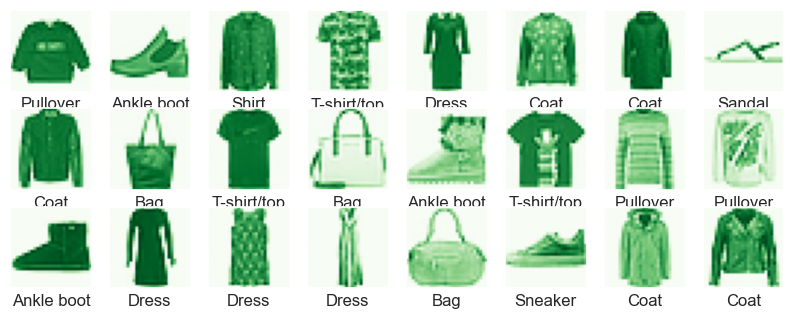

In [5]:

#Names of clothing accessories in order 
col_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

#Visualizing the images
plt.figure(figsize=(10,10))
for i in range(24):
    plt.subplot(8,8,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train[i].squeeze(), cmap='Greens')
    plt.xlabel(col_names[y_train[i].argmax()])
plt.show()


# Creating required model

In [6]:

model = Sequential()
model.add(Input(shape=(img_rows, img_cols, 1)))
# model.add(Conv2D(28, kernel_size=(3, 3), activation='relu'))
# model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(no_classes, activation='softmax'))


model.compile(loss=keras. losses.categorical_crossentropy, optimizer='adam', metrics=['accuracy'])


In [7]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,058,378 (7.85 MB)

 Trainable params: 2,058,378 (7.85 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(x=X_train, y=y_train, batch_size=100, epochs=10, validation_data=(X_test, y_test))


Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 65s 100ms/step - accuracy: 0.8337 - loss: 0.4630 - val_accuracy: 0.8911 - val_loss: 0.3041
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 66s 110ms/step - accuracy: 0.8945 - loss: 0.2930 - val_accuracy: 0.9091 - val_loss: 0.2476
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 56s 93ms/step - accuracy: 0.9130 - loss: 0.2389 - val_accuracy: 0.9181 - val_loss: 0.2234
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.9245 - loss: 0.2064 - val_accuracy: 0.9138 - val_loss: 0.2244
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 40s 66ms/step - accuracy: 0.9335 - loss: 0.1798 - val_accuracy: 0.9240 - val_loss: 0.2067
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.9431 - loss: 0.1547 - val_accuracy: 0.9290 - val_loss: 0.2019
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.9517 - loss: 0.1300 - val_accuracy: 0.9224 - val_loss: 0.2194
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 64s 107ms/step - accuracy: 0.9568 - loss: 0.1139

# Prediction

In [19]:
model.evaluate(X_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9290 - loss: 0.2213


[0.22125409543514252, 0.9290000200271606]

In [20]:
y_predict = model.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [21]:
print(y_predict.shape, y_test.shape)


(10000, 10) (10000, 10)


1


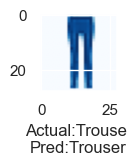

In [42]:
image_index = 700
pred = y_predict[image_index] 

print(pred.argmax())
plt.figure(figsize=[1,1])
plt.imshow(X_test[image_index].reshape(28, 28),cmap='Blues')
plt.xlabel("Actual:{}\nPred:{}".format(col_names[np.argmax(y_test[image_index])], col_names[pred.argmax()]))
plt.show()


### Visualising the Confusion Matrix using Heatmap

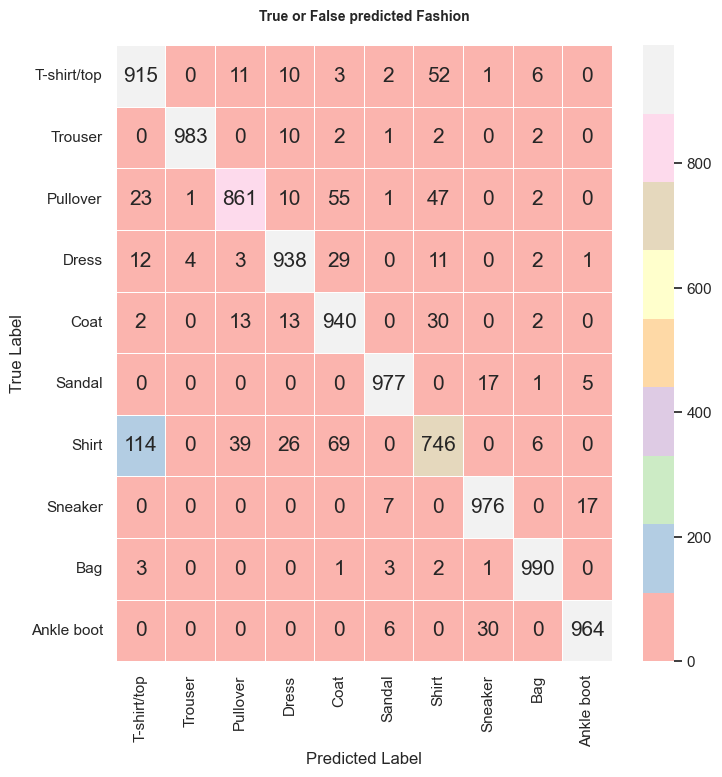

In [40]:
#Confusion matrix
con_mat = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(y_predict, axis=1))

# plt.style.use('ggplot')
plt.figure(figsize=(8,8))
sns.heatmap(con_mat, annot=True, annot_kws={'size': 15}, linewidths=0.5, fmt="d", cmap="Pastel1",
            xticklabels=col_names, yticklabels=col_names)
plt.xlabel('Predicted Label')
plt.yticks(rotation=0)
plt.ylabel('True Label')
plt.title('True or False predicted Fashion\n',fontweight='bold',fontsize=10)
plt.show()


### Classification Report

In [24]:
print(con_mat)


[[915   0  11  10   3   2  52   1   6   0]
 [  0 983   0  10   2   1   2   0   2   0]
 [ 23   1 861  10  55   1  47   0   2   0]
 [ 12   4   3 938  29   0  11   0   2   1]
 [  2   0  13  13 940   0  30   0   2   0]
 [  0   0   0   0   0 977   0  17   1   5]
 [114   0  39  26  69   0 746   0   6   0]
 [  0   0   0   0   0   7   0 976   0  17]
 [  3   0   0   0   1   3   2   1 990   0]
 [  0   0   0   0   0   6   0  30   0 964]]


# Accuracy and Loss Plot

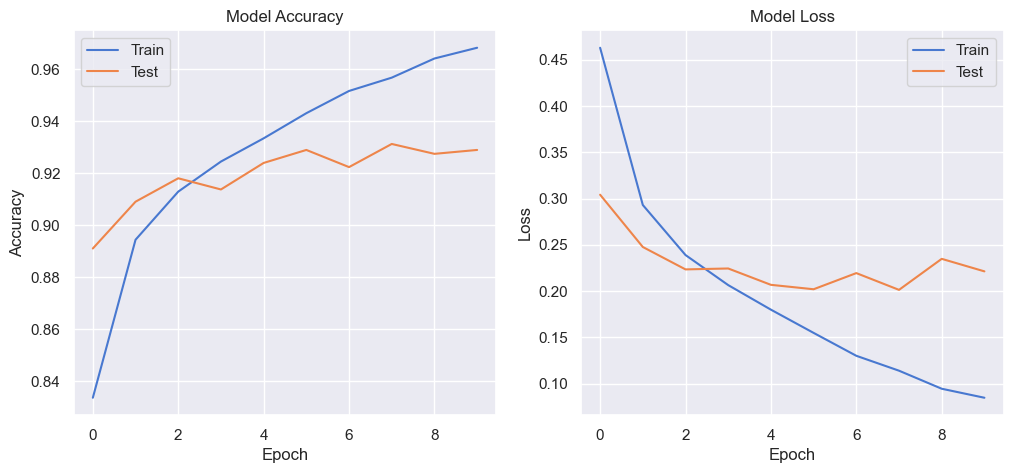

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')

plt.show()
